### Константы и импорты

In [293]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, kstwobign
from scipy.special import erf

part_value = [5, 8, 6, 12, 14, 18, 11, 6, 13, 7]
n = 100

# Пункт а

## Расчёт p-value через Хи квадрат

In [294]:
def calculate_the_delta():
    pi = 1/10
    delta = 0
    for i in range(10):
        delta += ((part_value[i] - n*pi)**2)/(n*pi)
    return delta
print(f"Дельта: {calculate_the_delta()}")
p_value_a_chi2 = chi2.sf(calculate_the_delta(), 9)
print(f"p-value: {p_value_a_chi2}")
    

Дельта: 16.4
p-value: 0.058984030544419454


## Расчёт p-value через критерий Колмогорова

In [295]:

def uniform_f(x):
    return x/10

def emp_f():
    F_emp = []
    cumulitive = 0
    for i in range(10):
        cumulitive += part_value[i] / 100
        F_emp.append(cumulitive)
    F_emp.insert(0, 0)
    return F_emp

F_emp = emp_f()

def calculate_delta():
    deltas_ = [0 for _ in range(10)]
    for i in range(10):
        uniform_val = uniform_f(i)
        deltas_[i] = max(abs(uniform_val - F_emp[i]), abs(F_emp[i+1] - uniform_val))
    delta = np.sqrt(n)*max(deltas_)
    return delta
print(f"Дельта: {calculate_delta()}")

def calculate_p_value(delta):
    p_value = 1 - kstwobign.cdf(delta)
    return p_value

print(f"p-value: {calculate_p_value(calculate_delta())}")

Дельта: 1.4000000000000001
p-value: 0.039681879538114306


# Пункт б

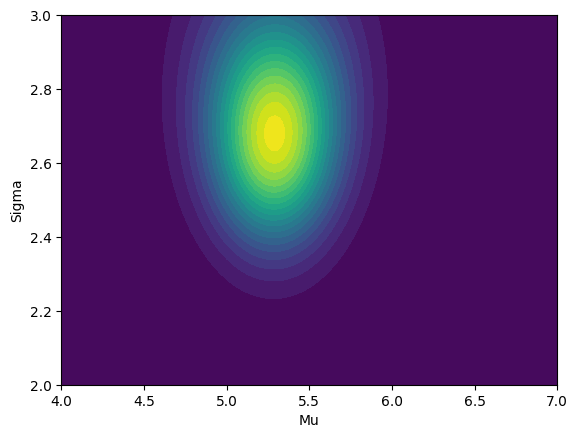

5.288288288288288 2.67967967967968


In [296]:
def p_norm(mu, sigma, x: np.array):
    return (1/(np.sqrt(2*np.pi)*sigma))*np.exp((-(x-mu)**2)/(2 * sigma**2))

def F(mu, sigma, x):
    return 0.5*(1+erf((x-mu)/(np.sqrt(2) * sigma)))

def p_i(a_i, b_i, mu, sigma):
    return F(mu, sigma, b_i) - F(mu, sigma, a_i)

def L(mu: np.array, sigma):
    mult = np.ones_like(mu)
    mult *= (p_i(-np.inf, 1, mu, sigma) ** part_value[0])
    for i in range(1, 9):
        mult *= (p_i(i, i+1, mu, sigma) ** part_value[i])
    mult *= (p_i(9, np.inf, mu, sigma) ** part_value[-1])
    return mult

def find_max_L():
    mu = np.linspace(4,7, 1000)
    sigma = np.linspace(2, 3, 1000)
    Mu, Sigma = np.meshgrid(mu, sigma)
    L_values = L(Mu, Sigma)
    figure, axis = plt.subplots()
    axis.contourf(Mu, Sigma, L_values, levels=20, cmap='viridis')
    axis.set_xlabel('Mu')
    axis.set_ylabel('Sigma')
    plt.show()

    flat_idx = np.argmax(L_values)
    i, j = np.unravel_index(flat_idx, L_values.shape)
    mu_max = Mu[i, j]
    sigma_max = Sigma[i, j]
    return mu_max, sigma_max

mu_max, sigma_max = find_max_L()
print(mu_max, sigma_max)

### Расчёт дельты

In [297]:
def calculate_delta_b():
    p_0 = p_i(-np.inf, 1, mu_max, sigma_max)
    delta = ((part_value[0] - n*p_0)**2)/(n*p_0)
    for i in range(1, 9):
        p_i_val = p_i(i, i+1, mu_max, sigma_max)
        delta += ((part_value[i] - n*p_i_val)**2)/(n*p_i_val)
    p_last = p_i(9, np.inf, mu_max, sigma_max)
    delta += ((part_value[9] - n*p_last)**2)/(n*p_last)
    return delta
delta = calculate_delta_b()
print(delta)

9.80508458788614


### Расчёт p-value

In [298]:
p_value = chi2.sf(delta, 7)
print(p_value)

0.19989086605461082


## Критерием Колмогорова

In [299]:
sample = np.repeat(np.arange(10), part_value)
mu_mean = np.mean(sample)
sigma_mean = np.std(sample)
print(mu_mean, sigma_mean)

4.77 2.505414137423193


In [300]:
def calculate_delta_b_kolm():
    deltas_ = [0 for _ in range(10)]
    for i in range(10):
        norm_val = F(mu_mean, sigma_mean, i)
        deltas_[i] = max(abs(norm_val - F_emp[i]), abs(F_emp[i+1] - norm_val))
    delta = np.sqrt(n)*max(deltas_)
    return delta
delta_est = calculate_delta_b_kolm()
print(f"Дельта: {calculate_delta_b_kolm()}")

Дельта: 1.0133711124224798


### Параметрический bootstrap

In [301]:
N = 50000

def emp_f_norm():
    return np.arange(n + 1) / n

def param_bootstrap_deltas(N):
    boot_deltas = np.zeros(N)
    for i in range(N):
        bootstrap_sample = np.sort(np.random.normal(loc = mu_mean, scale = sigma_mean, size = n))
        boot_mu = np.mean(bootstrap_sample)
        boot_sigma = np.std(bootstrap_sample)
        boot_F_emp = emp_f_norm()

        deltas_emp_f_ = np.zeros(n)
        for j in range(n):
            deltas_emp_f_[j] = max(abs(F(boot_mu, boot_sigma, bootstrap_sample[j]) - boot_F_emp[j]), \
                abs(boot_F_emp[j+1] - F(boot_mu, boot_sigma, bootstrap_sample[j])))
        delta_i = np.sqrt(n)*max(deltas_emp_f_)

        boot_deltas[i] = delta_i
    return boot_deltas

boot_deltas = param_bootstrap_deltas(N)
mask = boot_deltas >= delta_est
print(np.sum(mask)/N)


0.01352
